In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('Libraries imported successfully!')

Libraries imported successfully!


In [2]:
df = pd.read_csv('Advertising.csv')

print('Dataset loaded successfully!')
print('Shape:', df.shape)

Dataset loaded successfully!
Shape: (200, 5)


In [3]:
df.head(10)

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
5,6,8.7,48.9,75.0,7.2
6,7,57.5,32.8,23.5,11.8
7,8,120.2,19.6,11.6,13.2
8,9,8.6,2.1,1.0,4.8
9,10,199.8,2.6,21.2,10.6


In [4]:
print('Columns:')
print(df.columns.tolist())

print('\nData types:')
print(df.dtypes)

print('\nDataset information:')
df.info()

Columns:
['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales']

Data types:
Unnamed: 0      int64
TV            float64
Radio         float64
Newspaper     float64
Sales         float64
dtype: object

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [5]:
# Remove the unnecessary index column if it exists
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# Remove duplicate rows
df = df.drop_duplicates()

# Check missing values
print('Missing values:')
print(df.isnull().sum())

print('\nDuplicate rows:', df.duplicated().sum())
print('Cleaned shape:', df.shape)

Missing values:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Duplicate rows: 0
Cleaned shape: (200, 4)


In [6]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


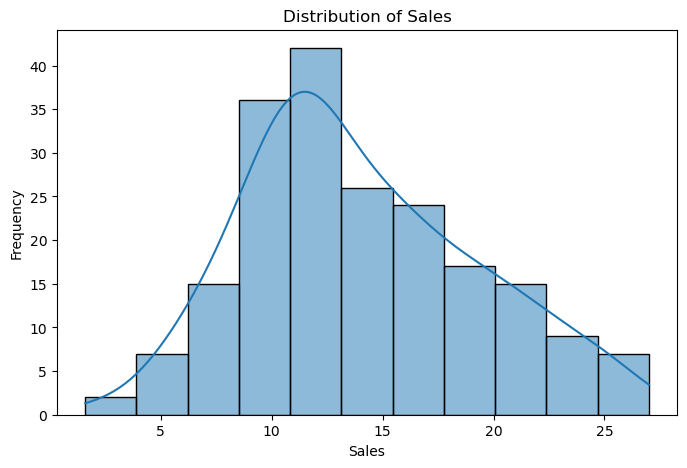

In [7]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Sales'], kde=True)
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

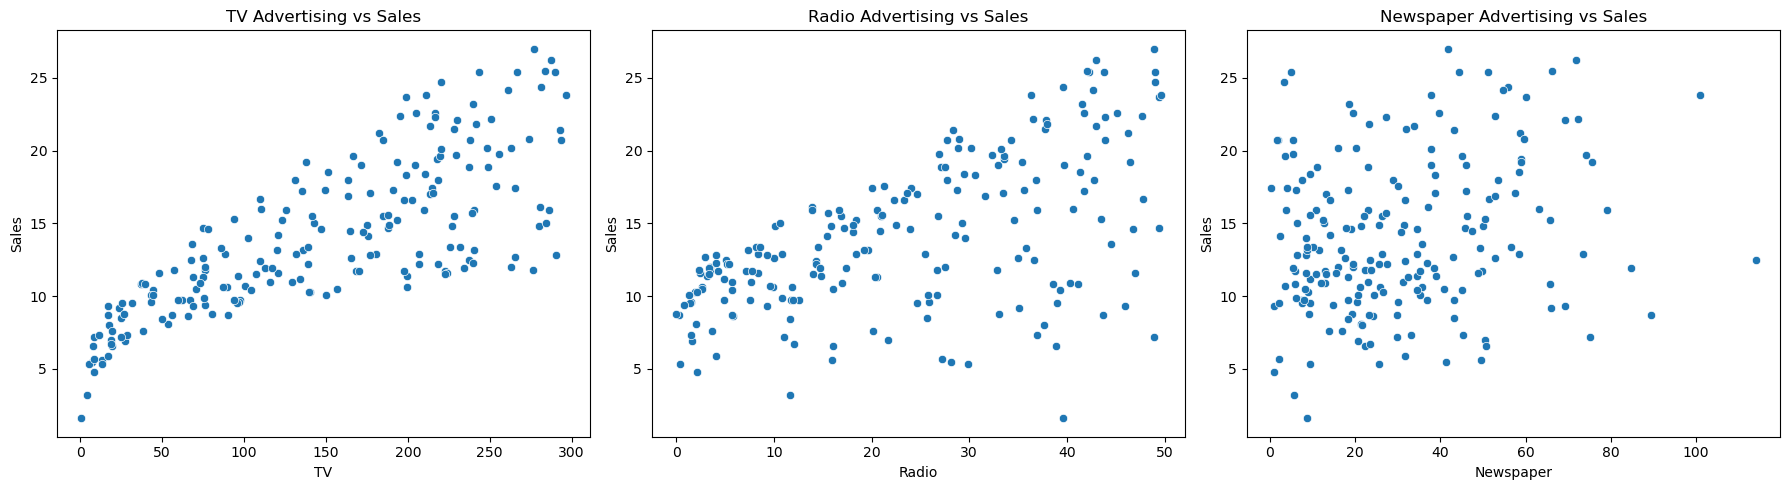

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

channels = ['TV', 'Radio', 'Newspaper']

for ax, channel in zip(axes, channels):
    sns.scatterplot(data=df, x=channel, y='Sales', ax=ax)
    ax.set_title(f'{channel} Advertising vs Sales')

plt.tight_layout()
plt.show()

## Cell 9 — Correlation Analysis

Sales        1.000000
TV           0.782224
Radio        0.576223
Newspaper    0.228299
Name: Sales, dtype: float64


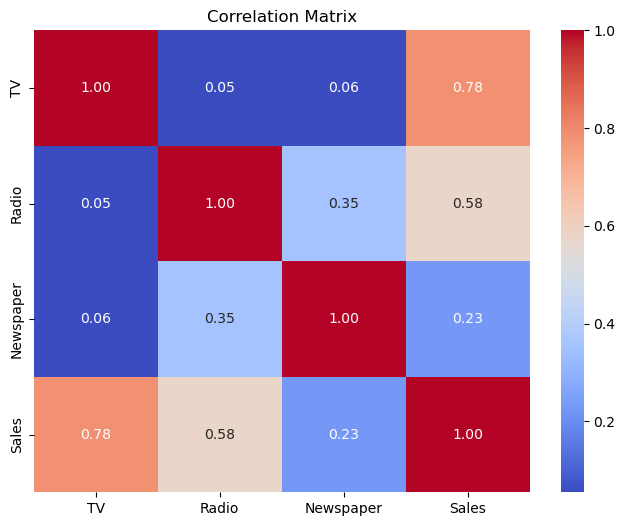

In [9]:
correlation = df.corr(numeric_only=True)
print(correlation['Sales'].sort_values(ascending=False))

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

## Cell 10 — Select Features and Target

In [10]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

print('Features:')
print(X.head())

print('\nTarget:')
print(y.head())

Features:
      TV  Radio  Newspaper
0  230.1   37.8       69.2
1   44.5   39.3       45.1
2   17.2   45.9       69.3
3  151.5   41.3       58.5
4  180.8   10.8       58.4

Target:
0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
Name: Sales, dtype: float64


## Cell 11 — Split Data into Training and Testing Sets

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print('Training rows:', X_train.shape[0])
print('Testing rows:', X_test.shape[0])

Training rows: 160
Testing rows: 40


## Cell 12 — Train the Linear Regression Model

In [12]:
model = LinearRegression()
model.fit(X_train, y_train)

print('Model trained successfully!')

Model trained successfully!


## Cell 13 — View Model Coefficients

In [13]:
coefficients = pd.DataFrame({
    'Advertising Channel': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

print('Intercept:', model.intercept_)
coefficients

Intercept: 2.9790673381226256


,Advertising Channel,Coefficient
1,Radio,0.189195
0,TV,0.044730
2,Newspaper,0.002761


### How to interpret coefficients

A positive coefficient means increasing that advertising channel is associated with higher predicted sales, while keeping the other channels constant.

The coefficient is **not** the same as a percentage increase in sales; it is the expected change in the Sales target for a one-unit increase in that feature.

## Cell 14 — Make Predictions on Test Data

In [14]:
y_pred = model.predict(X_test)

results = pd.DataFrame({
    'Actual Sales': y_test.values,
    'Predicted Sales': y_pred
})

results.head(10)

,Actual Sales,Predicted Sales
0,16.9,16.408024
1,22.4,20.889882
2,21.4,21.553843
3,7.3,10.608503
4,24.7,22.112373
5,12.6,13.105592
6,22.3,21.057192
7,8.4,7.461010
8,11.5,13.606346
9,14.9,15.155070


In [15]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error (MAE): {mae:.3f}')
print(f'Mean Squared Error (MSE): {mse:.3f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.3f}')
print(f'R² Score: {r2:.3f}')

Mean Absolute Error (MAE): 1.461
Mean Squared Error (MSE): 3.174
Root Mean Squared Error (RMSE): 1.782
R² Score: 0.899


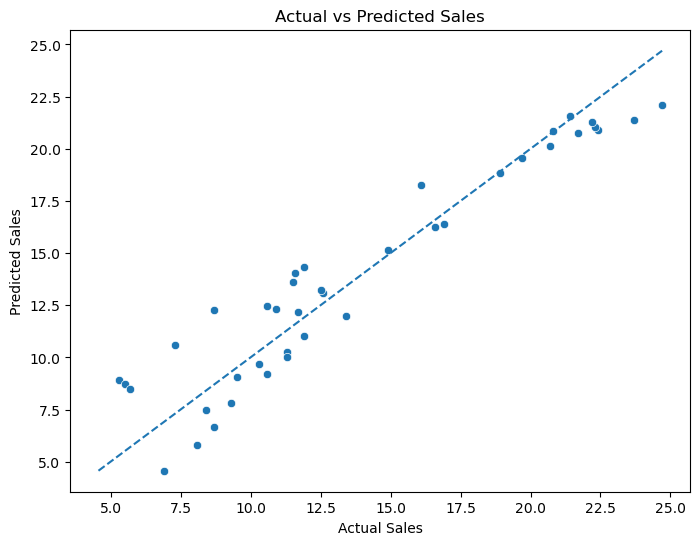

In [16]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle='--')
plt.show()

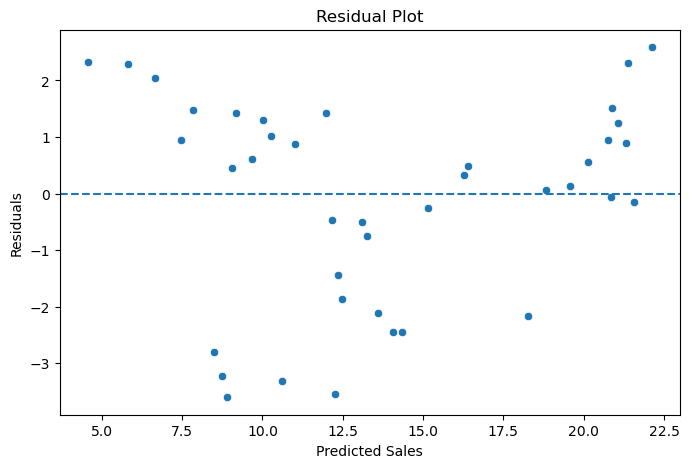

In [17]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, linestyle='--')
plt.xlabel('Predicted Sales')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

In [18]:
# Change these values to test different advertising budgets.
new_advertising = pd.DataFrame({
    'TV': [200],
    'Radio': [40],
    'Newspaper': [30]
})

predicted_sales = model.predict(new_advertising)[0]

print(f'Predicted Sales: {predicted_sales:.2f}')

Predicted Sales: 19.58


In [19]:
scenarios = pd.DataFrame({
    'Scenario': ['Low Budget', 'Medium Budget', 'High Budget'],
    'TV': [100, 200, 300],
    'Radio': [20, 40, 60],
    'Newspaper': [10, 30, 50]
})

scenarios['Predicted Sales'] = model.predict(
    scenarios[['TV', 'Radio', 'Newspaper']]
)

scenarios

,Scenario,TV,Radio,Newspaper,Predicted Sales
0,Low Budget,100,20,10,11.263531
1,Medium Budget,200,40,30,19.575606
2,High Budget,300,60,50,27.887682


## Cell 20 — Advertising Channel Impact

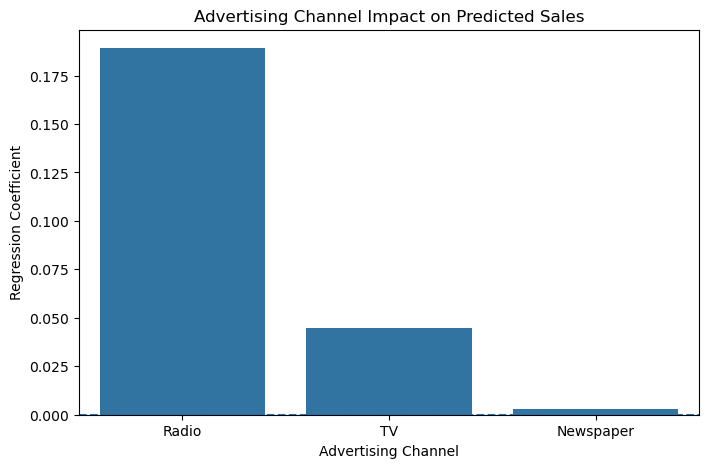

Most influential channel according to absolute regression coefficient:
Advertising Channel       Radio
Coefficient            0.189195
Name: 1, dtype: object


In [20]:
impact = coefficients.copy()
impact['Absolute Impact'] = impact['Coefficient'].abs()
impact = impact.sort_values('Absolute Impact', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=impact, x='Advertising Channel', y='Coefficient')
plt.axhline(0, linestyle='--')
plt.title('Advertising Channel Impact on Predicted Sales')
plt.ylabel('Regression Coefficient')
plt.show()

print('Most influential channel according to absolute regression coefficient:')
print(impact.iloc[0][['Advertising Channel', 'Coefficient']])

In [21]:
import joblib

joblib.dump(model, "sales_prediction_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [22]:
!pip install joblib

In [23]:
loaded_model = joblib.load("sales_prediction_model.pkl")

print("Saved model loaded successfully!")

Saved model loaded successfully!


In [24]:
new_data = pd.DataFrame({
    "TV": [250],
    "Radio": [50],
    "Newspaper": [25]
})

prediction = loaded_model.predict(new_data)

print(f"Predicted Sales: {prediction[0]:.2f}")

Predicted Sales: 23.69
